导入数据

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [4]:
# 加载数据
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

数据概况

In [4]:
# 查看前3行
print("\n训练集前3行:")
print(train.head(3))

# 查看数据概况
print("\n训练集信息:")
print(f"行数: {train.shape[0]}, 列数: {train.shape[1]}")


训练集前3行:
  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck             Name  \
0          0.0        0.0           0.0     0.0     0.0  Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0     Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0    Altark Susent   

   Transported  
0        False  
1         True  
2        False  

训练集信息:
行数: 8693, 列数: 14


Text(0.5, 1.0, 'Target distribution')

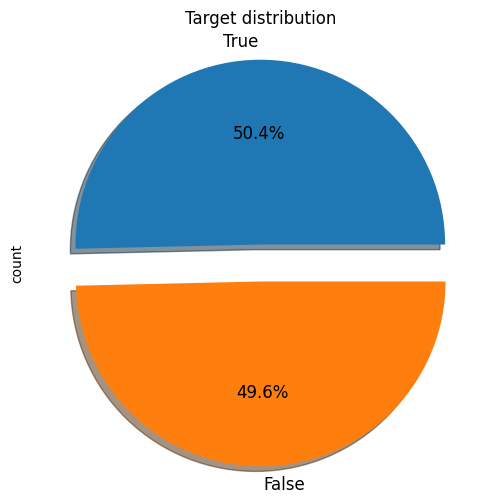

In [10]:
# Figure size
plt.figure(figsize=(6,6))

# transported分布饼图
train['Transported'].value_counts().plot.pie(explode=[0.1,0.1], autopct='%1.1f%%', shadow=True, textprops={'fontsize':12}).set_title("Target distribution")

Text(0.5, 0, 'Age (years)')

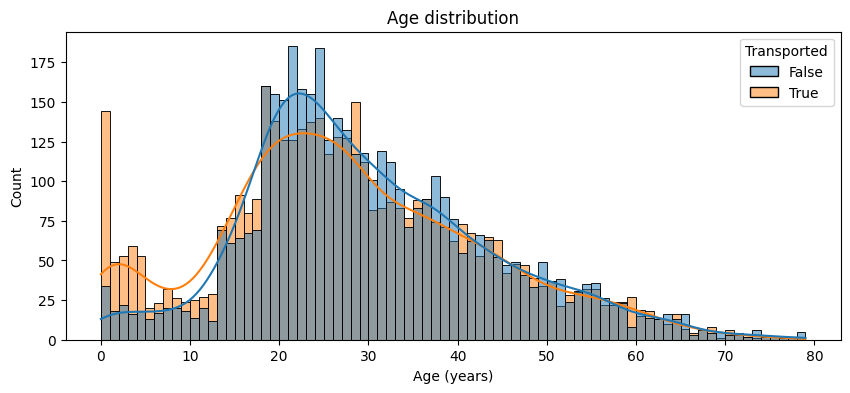

In [11]:
# Figure size
plt.figure(figsize=(10,4))

# 年龄分布直方图
sns.histplot(data=train, x='Age', hue='Transported', binwidth=1, kde=True)
plt.title('Age distribution')
plt.xlabel('Age (years)')

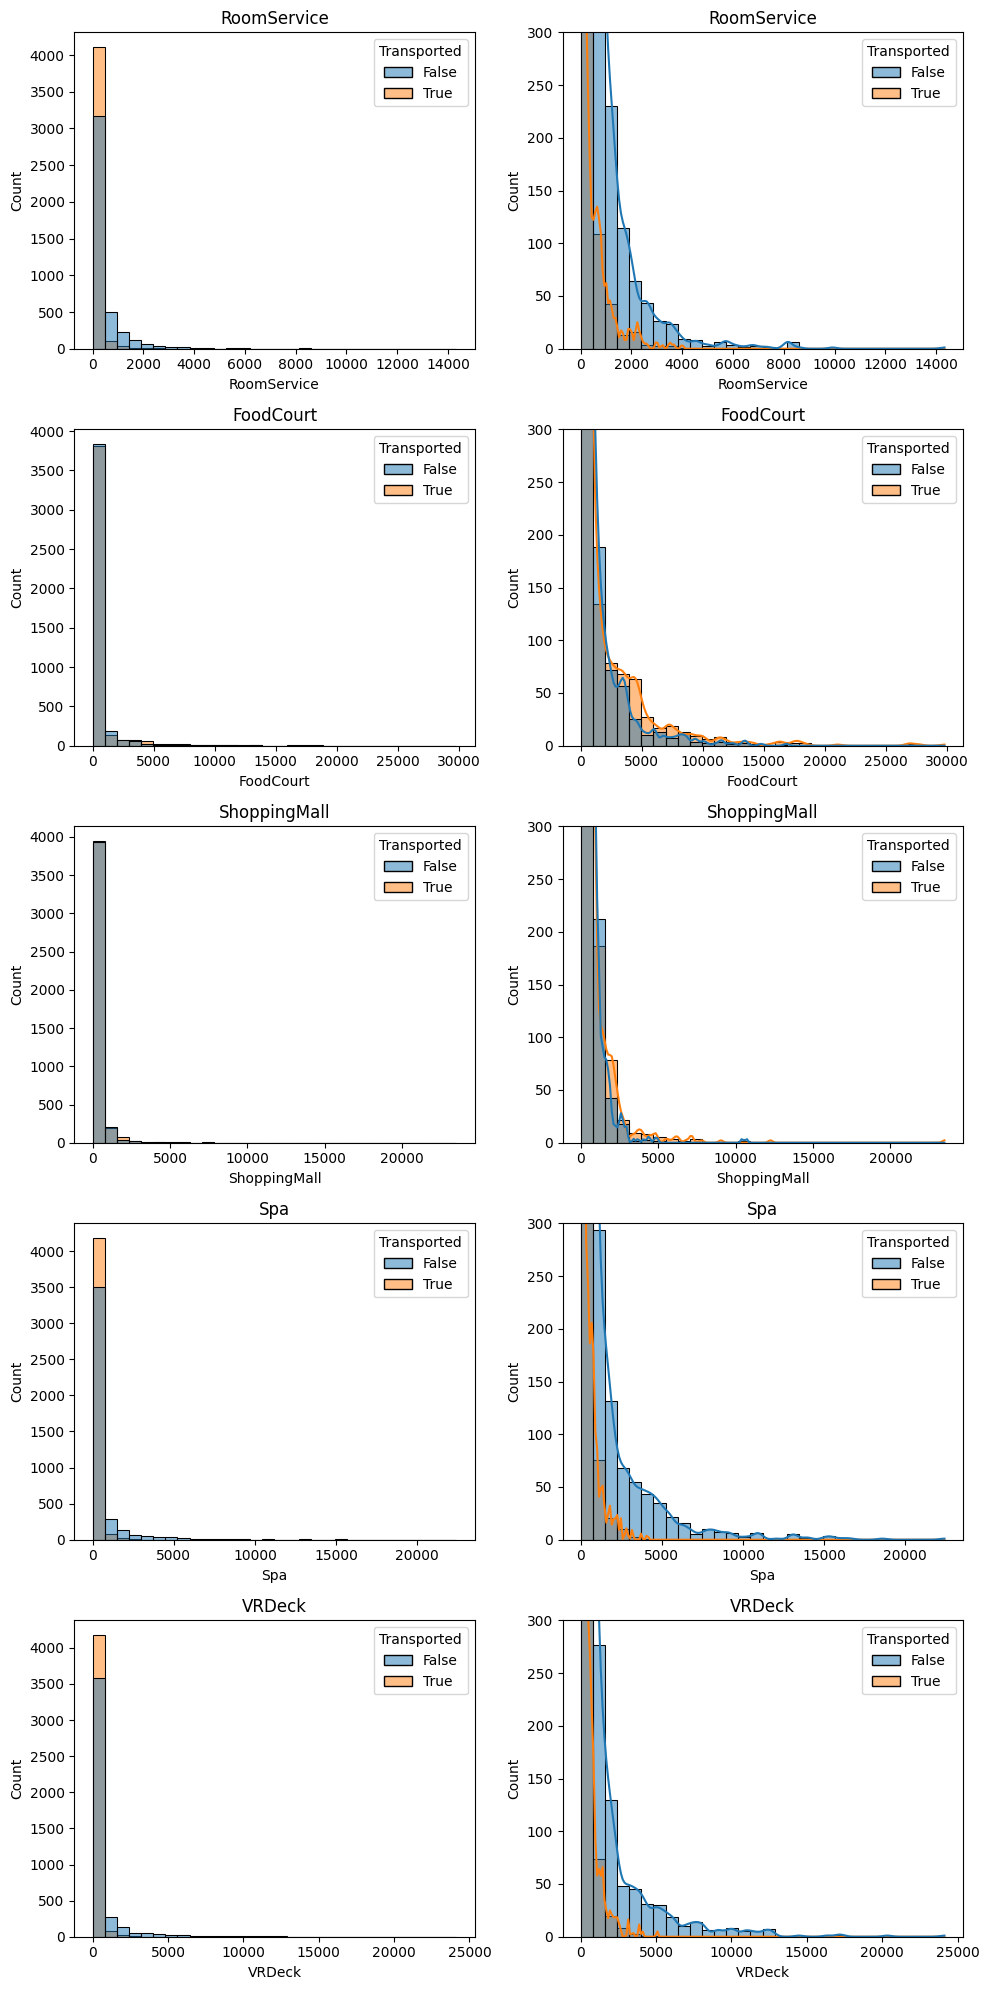

In [11]:
# 各消费字段分析
exp_feats=['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# Plot expenditure features
fig=plt.figure(figsize=(10,20))
for i, var_name in enumerate(exp_feats):
    #左边单纯统计频数
    ax=fig.add_subplot(5,2,2*i+1)
    sns.histplot(data=train, x=var_name, axes=ax, bins=30, kde=False, hue='Transported')
    ax.set_title(var_name)
    
    # 右边加上核密度曲线
    ax=fig.add_subplot(5,2,2*i+2)
    sns.histplot(data=train, x=var_name, axes=ax, bins=30, kde=True, hue='Transported')
    plt.ylim([0,300])#限制y轴高度，方便观察核密度估计曲线
    ax.set_title(var_name)
fig.tight_layout()  # Improves appearance a bit
plt.show()

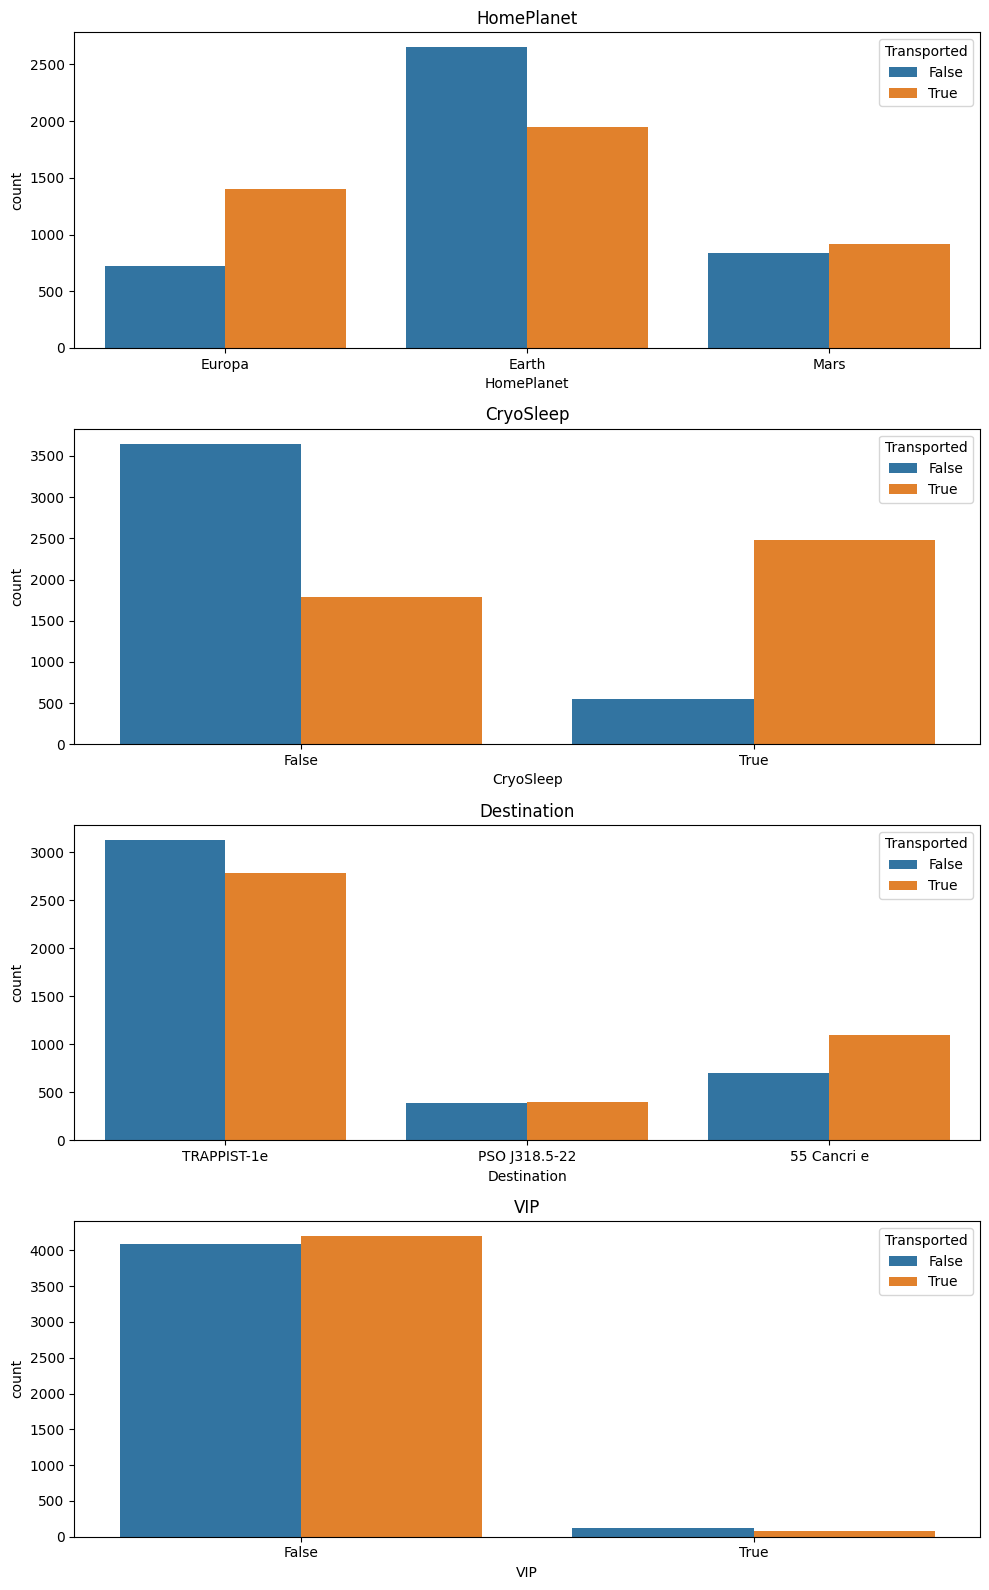

In [14]:
# 名义类特征
cat_feats=['HomePlanet', 'CryoSleep', 'Destination', 'VIP']

# 直方图统计频数
fig=plt.figure(figsize=(10,16))
for i, var_name in enumerate(cat_feats):
    ax=fig.add_subplot(4,1,i+1)
    sns.countplot(data=train, x=var_name, axes=ax, hue='Transported')
    ax.set_title(var_name)
fig.tight_layout()  # Improves appearance a bit
plt.show()


缺失值分析


缺失值数量
PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64


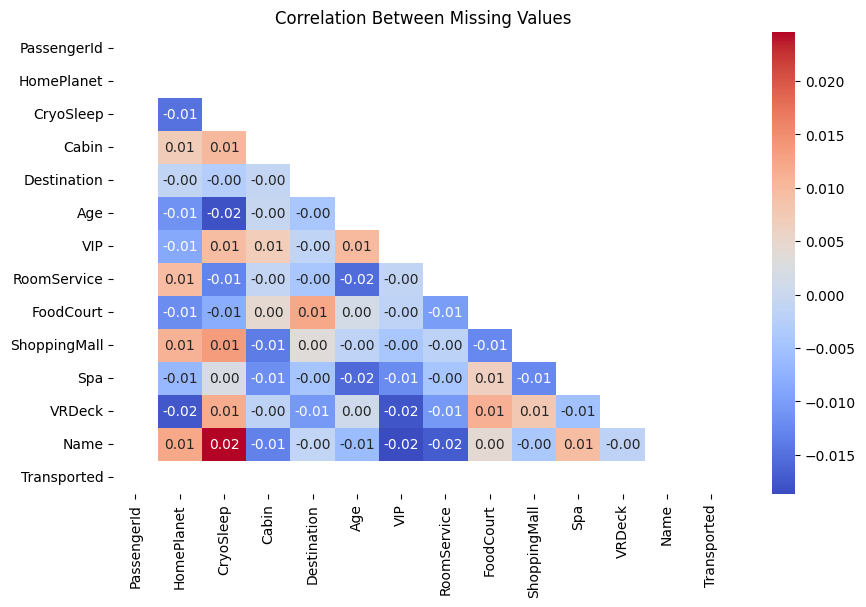

In [6]:
# 缺失值数量
print("\n缺失值数量")
print(train.isnull().sum())

# 生成缺失值指示矩阵（1=缺失，0=存在）
missing_indicator = train.isnull().astype(int)

# 计算缺失值之间的相关性
missing_corr = missing_indicator.corr()

# 绘制热力图
plt.figure(figsize=(10, 6))
sns.heatmap(missing_corr, annot=True, cmap='coolwarm', fmt=".2f", 
            mask=np.triu(np.ones_like(missing_corr, dtype=bool)))
plt.title("Correlation Between Missing Values", fontsize=12)
plt.show()

发现缺失值相关性很弱

缺失值处理

1. 若 CryoSleep=True，则所有消费字段应为0

In [7]:
# 定义消费字段
consumption_cols = ['RoomService', 'Spa', 'FoodCourt', 'ShoppingMall', 'VRDeck']

# 对于 CryoSleep=True 的乘客，消费列强制设为0
train.loc[train['CryoSleep'] == True, consumption_cols] = 0

2. 其它缺失值处理

In [8]:
initial_count = len(train)
train_dropped = train.dropna()
remaining_ratio = len(train_dropped) / initial_count
print(f"移除所有缺失行后剩余数据比例: {remaining_ratio:.2%}")

移除所有缺失行后剩余数据比例: 79.45%


最终选择直接删除

In [9]:
# 导出到csv
train_processed = train_dropped
train_processed.to_csv('train_processed_missing.csv',index = 'PassengerId')